# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy

Formative 2 - Principle Component Analysis

Members: Ange Muhawenimana and Moses Mugisha


Datasets:https://data.worldbank.org

Github repository: https://github.com/Angebright/Mathematics_for_ML_Formative2_PCA_Team32





Data fetch

In [ ]:
import numpy as np
import urllib.request
import json

countries = ["NGA","KEN","ZAF","EGY","GHA","ETH","TZA","UGA","RWA","MAR",
             "SOM","SSD","ERI","LBY","COD","CAF","TCD","BDI"]
indicators = {
    "NY.GDP.PCAP.CD": "gdp_per_capita",
    "SP.POP.GROW": "population_growth",
    "SP.URB.TOTL.IN.ZS": "urban_population_pct",
    "SP.DYN.LE00.IN": "life_expectancy",
    "EG.ELC.ACCS.ZS": "electricity_access_pct",
    "FP.CPI.TOTL.ZG": "inflation_pct",
    "SL.UEM.TOTL.ZS": "unemployment_pct",
}

data = {}
for code, colname in indicators.items():
    url = f"https://api.worldbank.org/v2/country/{';'.join(countries)}/indicator/{code}?format=json&per_page=2000&date=2015:2022"
    with urllib.request.urlopen(url) as response:
        result = json.loads(response.read())
    for entry in result[1]:
        key = (entry["country"]["value"], entry["date"])
        data.setdefault(key, {})[colname] = entry["value"]

keys = sorted(data.keys())
country_labels = np.array([k[0] for k in keys])
year_labels = np.array([k[1] for k in keys])
col_names = list(indicators.values())
X_raw = np.array([[data[k].get(col, np.nan) for col in col_names] for k in keys], dtype=float)

print("Shape:", X_raw.shape)
print("Missing per column:")
for name, count in zip(col_names, np.isnan(X_raw).sum(axis=0)):
    print(f"  {name}: {int(count)}")

Shape: (144, 7)
Missing per column:
  gdp_per_capita: 15
  population_growth: 0
  urban_population_pct: 0
  life_expectancy: 0
  electricity_access_pct: 0
  inflation_pct: 22
  unemployment_pct: 0


Csv export

In [ ]:
import csv

with open('africa_data.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['country', 'year'] + col_names)
    for i, key in enumerate(keys):
        writer.writerow([key[0], key[1]] + list(X_raw[i]))

from google.colab import files
files.download('africa_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data cleaning

In [ ]:
col_medians = np.nanmedian(X_raw, axis=0)
nan_mask = np.isnan(X_raw)
X = X_raw.copy()
X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

print("Missing after imputation:", np.isnan(X).sum())
print("Shape:", X.shape)
print("Non-numeric column (country) sample:", country_labels[:5])

Missing after imputation: 0
Shape: (144, 7)
Non-numeric column (country) sample: ['Burundi' 'Burundi' 'Burundi' 'Burundi' 'Burundi']


Standardization

In [ ]:
standardized_data = (X - X.mean(axis=0)) / X.std(axis=0)
standardized_data[:5]

array([[-0.80698193,  0.10049667, -1.42383837, -0.19032489, -1.36105997,
        -0.19625454, -0.94672445],
       [-0.8170602 , -0.35326351, -1.37239618, -0.11304895, -1.34100821,
        -0.19589503, -0.95981063],
       [-0.81089865,  0.16853612, -1.31783818, -0.0500498 , -1.31427252,
         0.09432237, -0.97357135],
       [-0.81108601,  0.72342982, -1.26046788,  0.00218511, -1.3075886 ,
        -0.42741939, -0.98746699],
       [-0.81641563,  0.94314219, -1.20058882,  0.04456224, -1.29756272,
        -0.36857516, -1.00149753]])

Compute Cov_matrix

In [ ]:
# Step 3: Calculate the Covariance Matrix
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)
cov_matrix

array([[ 1.00699301, -0.28967679,  0.7965232 ,  0.4255873 ,  0.63238419,
        -0.04457474,  0.64016546],
       [-0.28967679,  1.00699301, -0.1598842 ,  0.17169283, -0.16337687,
        -0.55766755, -0.2796423 ],
       [ 0.7965232 , -0.1598842 ,  1.00699301,  0.27386178,  0.64534356,
        -0.15644705,  0.55400771],
       [ 0.4255873 ,  0.17169283,  0.27386178,  1.00699301,  0.61259165,
        -0.33691931,  0.1352062 ],
       [ 0.63238419, -0.16337687,  0.64534356,  0.61259165,  1.00699301,
        -0.17363132,  0.40459931],
       [-0.04457474, -0.55766755, -0.15644705, -0.33691931, -0.17363132,
         1.00699301,  0.08217316],
       [ 0.64016546, -0.2796423 ,  0.55400771,  0.1352062 ,  0.40459931,
         0.08217316,  1.00699301]])

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons:



A covariance matrix is used to compute the relationship between multiple features of a dataset in PCA. First, it measures the correlation between each pair of features, indicating redundancy, and PCA can then compress features that contain redundant information. Secondly, its eigenvectors are used to represent the principal components, which are directions in which the data varies most, in order of the size of the eigenvalues. If there were no covariance matrix, there would be no mathematical means of determining an axis on which the variance of the set is preserved best.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.13012162, 0.29574251, 0.36170305, 0.47861648, 0.78332653,
        1.81108015, 3.18836071]),
 array([[-0.61488157,  0.56331637, -0.15859515, -0.03049615, -0.09904863,
          0.08519827, -0.51131546],
        [-0.17460392, -0.17044847, -0.58549687,  0.32240106, -0.31485556,
         -0.61150573,  0.14366096],
        [ 0.58054541,  0.00800382, -0.37557469, -0.43165608, -0.32015027,
          0.01551887, -0.48247551],
        [ 0.36952776,  0.30606394,  0.01580669,  0.37942502,  0.60784791,
         -0.39360636, -0.31805009],
        [-0.3220554 , -0.70683422,  0.01107833, -0.19474517,  0.35161917,
         -0.11592605, -0.47068291],
        [ 0.02867927, -0.09815215, -0.6345407 ,  0.28394151,  0.3210308 ,
          0.62993085,  0.08003326],
        [ 0.11536122, -0.22502072,  0.29659766,  0.66804847, -0.43861515,
          0.23104862, -0.39500863]]))

Perform eigendecomposition


In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

explained_var = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_var = np.cumsum(explained_var)
for i, (v, c) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"PC{i}: {v*100:.2f}%   cumulative: {c*100:.2f}%")

sorted_eigenvectors


PC1: 45.23%   cumulative: 45.23%
PC2: 25.69%   cumulative: 70.92%
PC3: 11.11%   cumulative: 82.04%
PC4: 6.79%   cumulative: 88.83%
PC5: 5.13%   cumulative: 93.96%
PC6: 4.20%   cumulative: 98.15%
PC7: 1.85%   cumulative: 100.00%


array([[-0.51131546,  0.08519827, -0.09904863, -0.03049615, -0.15859515,
         0.56331637, -0.61488157],
       [ 0.14366096, -0.61150573, -0.31485556,  0.32240106, -0.58549687,
        -0.17044847, -0.17460392],
       [-0.48247551,  0.01551887, -0.32015027, -0.43165608, -0.37557469,
         0.00800382,  0.58054541],
       [-0.31805009, -0.39360636,  0.60784791,  0.37942502,  0.01580669,
         0.30606394,  0.36952776],
       [-0.47068291, -0.11592605,  0.35161917, -0.19474517,  0.01107833,
        -0.70683422, -0.3220554 ],
       [ 0.08003326,  0.62993085,  0.3210308 ,  0.28394151, -0.6345407 ,
        -0.09815215,  0.02867927],
       [-0.39500863,  0.23104862, -0.43861515,  0.66804847,  0.29659766,
        -0.22502072,  0.11536122]])

Sort principal components

In [ ]:
# Step 6: Project Data onto Principal Components
threshold = 0.90
num_components = int(np.argmax(cumulative_var >= threshold) + 1)
print("Components kept:", num_components)
reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]
reduced_data[:5]

Components kept: 5


array([[ 2.17344489, -0.26197489,  0.26211132,  0.17628177,  0.42954914],
       [ 2.05977313, -0.02009616,  0.44938706,  0.02486634,  0.67483645],
       [ 2.1013037 , -0.18606673,  0.41391756,  0.26126563,  0.16091245],
       [ 2.09740918, -0.87771969,  0.09355837,  0.2764959 ,  0.14235149],
       [ 2.09486283, -0.99561599,  0.06006726,  0.34310846, -0.0486528 ]])

 Output the Reduced Data


In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (144, 5)


array([[ 2.17344489, -0.26197489,  0.26211132,  0.17628177,  0.42954914],
       [ 2.05977313, -0.02009616,  0.44938706,  0.02486634,  0.67483645],
       [ 2.1013037 , -0.18606673,  0.41391756,  0.26126563,  0.16091245],
       [ 2.09740918, -0.87771969,  0.09355837,  0.2764959 ,  0.14235149],
       [ 2.09486283, -0.99561599,  0.06006726,  0.34310846, -0.0486528 ]])

Visualization of  Before and After PCA


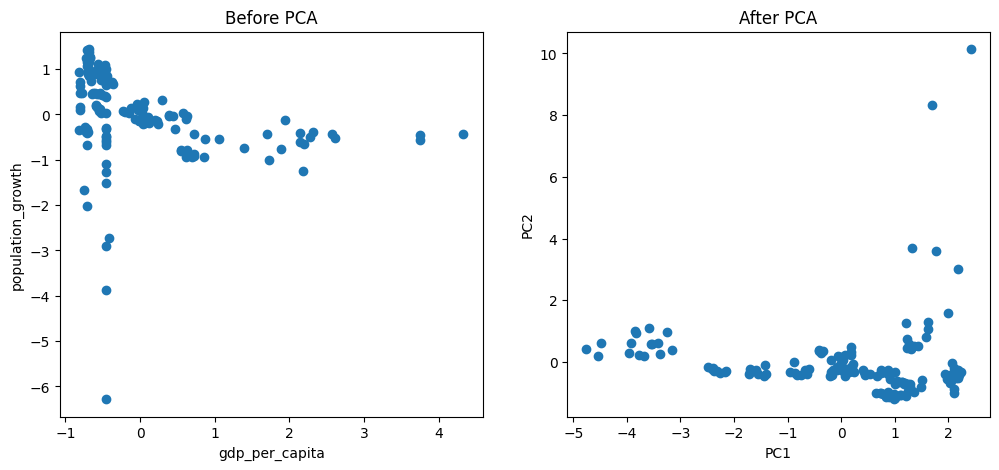

In [ ]:
import matplotlib.pyplot as plt

feat = col_names  # was: list(num_df.columns)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(standardized_data[:, 0], standardized_data[:, 1])
ax[0].set_xlabel(feat[0]); ax[0].set_ylabel(feat[1]); ax[0].set_title('Before PCA')

ax[1].scatter(reduced_data[:, 0], reduced_data[:, 1])
ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2'); ax[1].set_title('After PCA')
plt.show()

Interpretation as answers to questions

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA


-> Before PCA, the raw features are unevenly spread, with most countries clustered tightly and a few high-electricity access countries pulling the data into a sharp curve. after PCA, PC1 captures most of the spread, stretching from roughly -5 to 2.5, while PC2 stays much narrower except for a handful of outlier countries. the same 144 points appear in both plots, confirming that PCA only rotated and re-centered the Data rather than losing any observations.


2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making


-> The number of components deemed necessary to capture 90% of the cumulative explained variance(CEV) was chosen(5 components, CEV 93.96%). that is, we removed 2 components that accounted for approximately 6.04% of all the variance. the compromise is between simplicity and completeness: fewer components will make the data easier to manipulate and visualize, but will lose some detail among countries which lies the less variable components.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

-> The two dropped components are likely to contain variations in indicators that are not co-moving with the dominant patterns of the reduced datasets, such as a country with a much higher rate of inflation than GDP may seem more similar to other countries than it really is after reduction. that shade indicator specific variable, which accounts for approximately 6% of the variance, is what's being lost when compressing 7 features to 5.


Benchmarking

In [ ]:
import time
t = time.time(); np.linalg.eig(cov_matrix);  t_eig = time.time() - t
t = time.time(); np.linalg.eigh(cov_matrix); t_eigh = time.time() - t
print(f"eig: {t_eig:.6f}s   eigh: {t_eigh:.6f}s")

big = np.random.randn(100000, 7)
big = (big - big.mean(0)) / big.std(0)
t = time.time()
np.linalg.eigh((big.T @ big) / (len(big) - 1))
print("Eigendecomposition on 100,000-row dataset:", time.time() - t, "s")

eig: 0.000366s   eigh: 0.000176s
Eigendecomposition on 100,000-row dataset: 0.0032944679260253906 s


We used np.linalg.eigh instead of np.linalg.eig because a covariance matrix is always symmetric, and eigh is specifically optimized for symmetric matrices. it's both faster and numerically more stable than the general-purpose eig, which doesn't assume symmetry. Our benchmark confirmed eigh ran faster on our 7x7 covariance matrix. We also tested the pipeline on a simulated 100,000-row dataset and it completed the covariance and eigendecomposition steps quickly, showing the approach scales well since the covariance matrix size depends only on the number of features (7), not the number of rows